In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import colormaps
import numpy as np
import geopandas as gpd
import fiona
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from scipy import stats

#### All Data Retrieved from data.gov or WA State opensource data repositories

# Dataframes

## Total Vehicles (2017-2025)
### Total number of vehicles registered in WA state from 2017 through 2025

In [2]:
tot_veh_df=pd.read_csv('/Users/bathnayfleurima/Library/Mobile Documents/com~apple~CloudDocs/Data Analysis/Newly_Registered_Vehicles_by_Class_and_County_20260126 (1).csv')
tot_veh_df['Count']=tot_veh_df['Count'].apply(pd.to_numeric, errors='coerce')
tot_veh_df=tot_veh_df.rename(columns={'Residential County': 'JURISDICT_LABEL_NM'})
tot_veh_df.head(10)


,Fiscal Year,Transaction Date,Transaction County,JURISDICT_LABEL_NM,Fuel Type,Primary Use Class,Count
0,2017,1/31/17,Adams,Adams,Gasoline,Passenger Vehicle,19.0
1,2017,1/31/17,Adams,Adams,Gasoline,Farm Use,2.0
2,2017,1/31/17,Adams,Adams,Gasoline,Farm Exempt,1.0
3,2017,1/31/17,Adams,Adams,Gasoline,Exempt (State/County/Local/Tribal),1.0
4,2017,1/31/17,Adams,Adams,Diesel,Truck,2.0
5,2017,1/31/17,Adams,Adams,Gasoline,Motorcycle,1.0
6,2017,1/31/17,Adams,Adams,Diesel,Farm Exempt,1.0
7,2017,1/31/17,Adams,Adams,Gasoline,Truck,5.0
8,2017,1/31/17,Adams,Grant,Gasoline,Passenger Vehicle,1.0
9,2017,1/31/17,Adams,Franklin,Diesel,Truck,1.0


In [3]:
# Aggregating all gas powered fuel types
ft_df=tot_veh_df.loc[(tot_veh_df['Fuel Type']=='Gasoline') | (tot_veh_df['Fuel Type']=='Flex Fuel/Gasoline') |
    (tot_veh_df['Fuel Type']=='Diesel') | (tot_veh_df['Fuel Type']=='Hybrid') | (tot_veh_df['Fuel Type']=='Electric')] # Creating a new df with selected fuel types  
                                                                                                                            #(a quicker option is to index the fuel type and pass a list of in the loc of the desired items)
ft_table=pd.pivot_table(ft_df,index=['JURISDICT_LABEL_NM','Fiscal Year'], columns='Fuel Type',values='Count', aggfunc="sum") # Pivoting the df into a table and summing the fuel types
ft_table['Gas Power']=ft_table['Gasoline']+ft_table['Flex Fuel/Gasoline']+ft_table['Diesel'] # Adding a new column to the table (aggregating the different fossil fuel types)
ft_table=ft_table.drop(['Diesel','Flex Fuel/Gasoline','Gasoline'], axis=1) # Removing the individually aggregated fossil fuel type columns
ft_table.head(10)  # Total vehicles by county, fuel type and year

Fuel Type                       Electric  Hybrid  Gas Power
JURISDICT_LABEL_NM Fiscal Year                             
Adams              2017              1.0     5.0      766.0
                   2018              3.0    14.0     1392.0
                   2019              1.0    18.0     1422.0
                   2020              4.0    20.0     1308.0
                   2021              7.0    30.0     1445.0
                   2022              5.0    35.0     1254.0
                   2023             16.0    36.0     1271.0
                   2024             14.0    55.0     1208.0
                   2025             19.0    31.0      622.0
Asotin             2017              2.0    16.0     1316.0

In [4]:
ft_table_avg=ft_table.groupby(level=['JURISDICT_LABEL_NM']).mean() 
ft_table_avg.head(5) # avg daily vehicle registration by county (2017-2025)

Fuel Type,Electric,Hybrid,Gas Power
JURISDICT_LABEL_NM,,,
Adams,7.777778,27.111111,1187.555556
Asotin,8.222222,38.666667,1906.111111
Benton,247.333333,602.888889,13896.333333
Chelan,124.888889,201.333333,4608.888889
Clallam,110.555556,313.000000,4339.000000


## Electric Vehicles

In [5]:
evdf=pd.read_csv('/Users/bathnayfleurima/Library/Mobile Documents/com~apple~CloudDocs/Data Analysis/Electric_Vehicle_Population_Data.csv')
wa_evdf=evdf.loc[evdf['State']=='WA']
wa_evdf.set_index('County').head(5) # WA state 2025 electric vehicles df

,VIN (1-10),City,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Legislative District,DOL Vehicle ID,Vehicle Location,Electric Utility,2020 Census Tract
County,,,,,,,,,,,,,,,
Thurston,5YJYGDEE8L,Tumwater,WA,98501.0,2020,TESLA,MODEL Y,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,291.0,35.0,124633715,POINT (-122.89165 47.03954),PUGET SOUND ENERGY INC,5.306701e+10
Snohomish,5YJXCAE2XJ,Bothell,WA,98021.0,2018,TESLA,MODEL X,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,238.0,1.0,474826075,POINT (-122.18384 47.8031),PUGET SOUND ENERGY INC,5.306105e+10
King,5YJ3E1EBXK,Kent,WA,98031.0,2019,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,220.0,47.0,280307233,POINT (-122.17743 47.41185),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),5.303303e+10
King,7SAYGDEE4T,Issaquah,WA,98027.0,2026,TESLA,MODEL Y,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0.0,41.0,280786565,POINT (-122.03439 47.5301),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),5.303302e+10
King,WAUUPBFF9G,Seattle,WA,98103.0,2016,AUDI,A3,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,16.0,43.0,198988891,POINT (-122.35436 47.67596),CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),5.303300e+10


## Income

In [6]:
wa_income=pd.read_excel('/Users/bathnayfleurima/Library/Mobile Documents/com~apple~CloudDocs/Data Analysis/median_household_income_estimates.xlsx',skiprows=[0,1,2,4],header=0,skipfooter=15,index_col=0)
wa_income.head(5) # WA state yearly income by county (1989 -2024)


,1989,1990,1991,1992,1993,1994,1995,1996,1997,1998,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
Washington,31183,33417.061,34379.118,35881.524,36678.568,37894.965,38996.782,40568.226,42399.362,44514.015,...,63439.20,65500.290875,69287.868831,72297.030172,78674,80319,84155,91255,94553.000000,97970.191321
Adams,24604,28024.074,27300.700,28328.127,31277.360,29537.150,29603.720,31806.107,31794.792,34072.856,...,47645.73,49501.385091,48848.793830,52870.057114,53535,56421,57405,62410,67056.000000,72047.863099
Asotin,22897,24206.219,25110.440,26250.554,27358.886,27872.895,28288.256,29812.595,31498.836,32476.597,...,46107.27,47020.113312,51766.880459,50746.366302,54776,53377,56438,65625,67820.196013,63963.649844
Benton,32593,35011.606,37093.354,39227.763,41153.190,42789.890,42539.628,42816.605,44056.502,45665.234,...,62071.02,62282.049221,63501.707462,67912.297802,72847,75882,77339,85144,87992.118389,80987.992107
Chelan,24312,25833.442,27592.308,28745.697,30148.302,31546.570,32163.776,33918.164,35661.808,37174.884,...,53067.96,55109.142422,60790.913046,60747.403036,59838,61546,64700,81697,84429.814151,76794.048000


In [7]:
wa_income=wa_income.drop(index='Washington') # Removing row named/index 'Washington'
wa_income=wa_income.loc[:,'2017':'2024'] # Selecting columns 2017 through 2024
wa_income['Sum']=wa_income.sum(axis=1, numeric_only=True) #Adding sum column
wa_income['Mean']=wa_income.mean(axis=1) # Adding mean column


## Population

In [8]:
pop_wadf=pd.read_excel('/Users/bathnayfleurima/Library/Mobile Documents/com~apple~CloudDocs/Data Analysis/ofm_april1_population_final.xlsx', header=4, skipfooter=2, index_col='County')
pop_wadf=pop_wadf.drop(['Line','Filter','Jurisdiction'], axis=1) #Removing unnecessary columns 
pop_wadf=pop_wadf.groupby(level=['County']).sum() # Grouping by county and summing
pop_wadf=pop_wadf.drop(index=['.','State']) # removing unnecessary rows named 'State' and '.'
pop_wadf['Mean_Population']=pop_wadf.mean(axis=1) # Adding a new column (mean population by county (2020-2025)
pop_wadf['Mean_Population']=pop_wadf['Mean_Population'].apply(pd.to_numeric, errors='coerce') # changing the column's data type 
pop_wadf.head(5)

,2020 Population Census,2021 Population Estimate¹,2022 Population Estimate,2023 Population Estimate,2024 Population Estimate,2025 Population Estimate,Mean_Population
County,,,,,,,
Adams,52367,53125,53725,54015,54797,55010,53839.833333
Asotin,52935,53430,53635,53745,53915,53965,53604.166667
Benton,584063,591440,599455,608885,615745,620895,603413.833333
Chelan,204916,206860,208490,210625,212580,214155,209604.333333
Clallam,185629,187080,187025,188135,189330,189575,187795.666667


## GEO

In [9]:
wa_evgdf=gpd.read_file('/Users/bathnayfleurima/Library/Mobile Documents/com~apple~CloudDocs/Data Analysis/WA_County_Boundaries.geojson') #df with geo data
wa_evgdf=wa_evgdf.sort_values(by='JURISDICT_NM')
wa_evgdf.insert(0,'2024 Income', value=wa_income[2024].values)

wa_evgdf=wa_evgdf.set_index('JURISDICT_LABEL_NM') #.join(ft_grp.set_index('JURISDICT_LABEL_NM'))
wa_evgdf=wa_evgdf.join(wa_income.loc[:,'Sum':'Mean']) # Adding sum and mean columns from income df
wa_evgdf=wa_evgdf.rename(columns={'Sum': 'Sum_Income','Mean':'Mean_Income'}) # rename columns for consistency
wa_evgdf=wa_evgdf[['2024 Income','geometry','Sum_Income','Mean_Income']] # creating a df with income and geo
wa_evgdf=wa_evgdf.join(ft_table_avg.rename(columns={'Electric':'Mean_Electric','Hybrid':'Mean_Hybrid','Gas Power':'Mean_GasPower'})) # Adding EV data to the df
wa_evgdf.insert(7,'Mean_Population', value= pop_wadf['Mean_Population'].values) # Adding population column to df
wa_evgdf.head(5)

,2024 Income,geometry,Sum_Income,Mean_Income,Mean_Electric,Mean_Hybrid,Mean_GasPower,Mean_Population
JURISDICT_LABEL_NM,,,,,,,,
Adams,72047.863099,"POLYGON ((-117.96093 47.26057, -117.9737 47.26...",470593.714042,104576.380898,7.777778,27.111111,1187.555556,53839.833333
Asotin,63963.649844,"POLYGON ((-117.19986 46.42018, -117.20215 46.4...",464513.092617,103225.131693,8.222222,38.666667,1906.111111,53604.166667
Benton,80987.992107,"POLYGON ((-119.40713 46.64043, -119.40741 46.6...",611606.115760,135912.470169,247.333333,602.888889,13896.333333,603413.833333
Chelan,76794.048000,"POLYGON ((-120.83863 48.55084, -120.83951 48.5...",550543.178233,122342.928496,124.888889,201.333333,4608.888889,209604.333333
Clallam,67451.142414,"POLYGON ((-123.63454 48.23503, -123.63456 48.2...",481404.734222,106978.829827,110.555556,313.000000,4339.000000,187795.666667


# Lists

In [10]:
county_list=list(wa_evdf['County']) # List of WA state counties


# Dictionaries

In [11]:
county_df=[]  
ct_df_dict={}   
for frames in wa_evdf.groupby(wa_evdf['County']):
# Each "frames" is a tuple with a dataframe by county
    county_df.append(frames)
   # Accessing the county and linking it to its dataframe in a dict:
    ct_df_dict[frames[0]]=frames[1]


# DESCRIPTIVE ANALYSIS

###  Stats by County (2017-2024) 

In [12]:
wa_evgdf.explore(column='Mean_Electric', tooltip=['JURISDICT_LABEL_NM','Mean_Income','Mean_Electric','Mean_Population'],  tiles="CartoDB positron", style_kwds={'color':'blue'})
# Interactive map of WA by avg daily electric vehicle registration with additional income, ev registration, and population information

### WA State Vehicles Overtime and by County (2017-2025)

<Axes: title={'center': 'Avg Yearly Population by County (2020-2025)'}, xlabel='JURISDICT_LABEL_NM'>

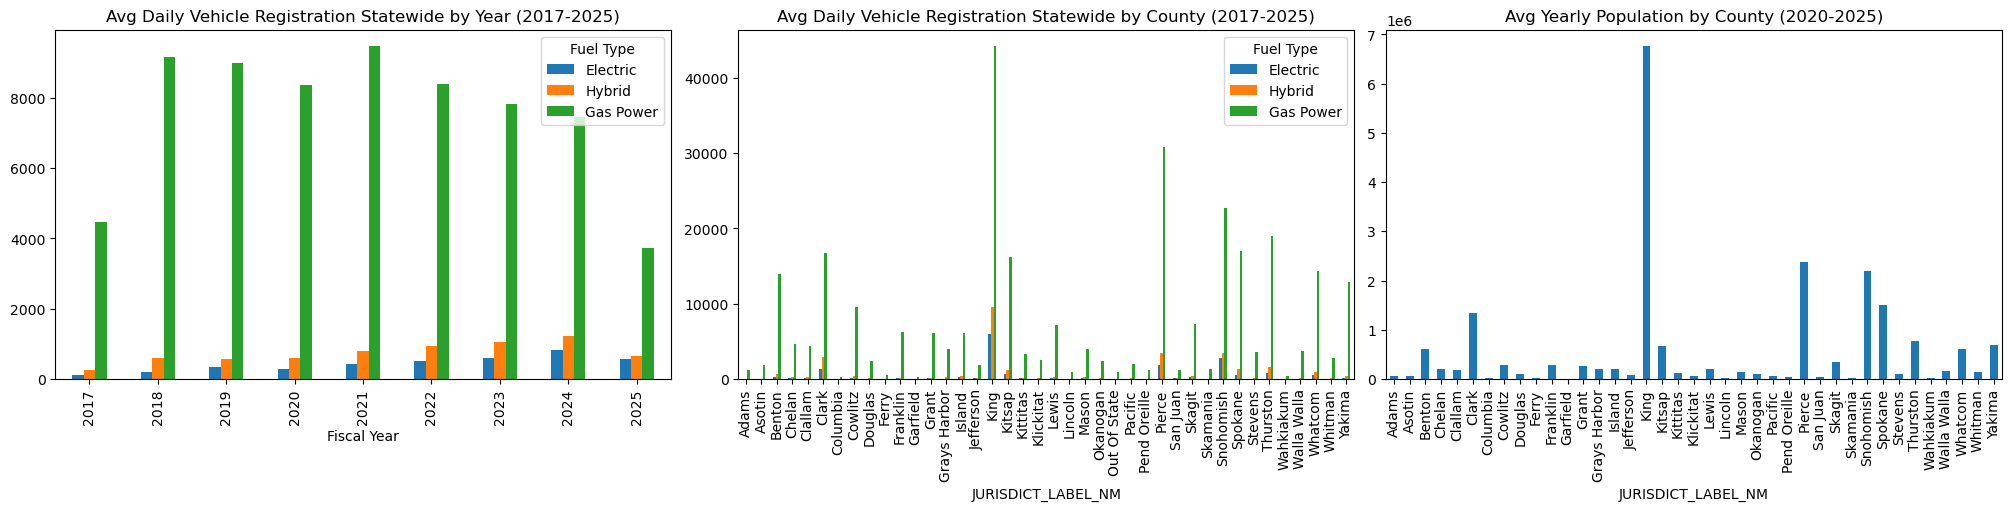

In [13]:
fig, axs=plt.subplots(ncols=3, nrows=1, layout='constrained') # setting the figure with 3 columns and 1 row

ft_table.groupby('Fiscal Year').mean().plot(ax=axs[0], kind='bar', figsize=(25,5), title='Avg Daily Vehicle Registration Statewide by Year (2017-2025)')   
ft_table.groupby('JURISDICT_LABEL_NM').mean().plot(ax=axs[1], kind='bar', title='Avg Daily Vehicle Registration Statewide by County (2017-2025)') 
wa_evgdf['Mean_Population'].plot(ax=axs[2], kind='bar', figsize=(20,5), title='Avg Yearly Population by County (2020-2025)')
#pop_wadf['Mean_Population'].plot(ax=ax3, kind='bar', title='Avg Population by County (2020-2025)')

## EV Adoption Predictor(s)

In [30]:
lr=LinearRegression()
X=wa_evgdf[['Mean_Income']]
Y=wa_evgdf['Mean_Electric']
lr.fit(X,Y)
Y_Pred=lr.predict(X)
print('The coefficient of determination is:', r2_score(Y,Y_Pred))
print('62% of variation in Mean_Electric predictions are explained by Mean_Income')

The coefficient of determination is: 0.6206307364823054
62% of variation in Mean_Electric predictions are explained by Mean_Income


## Correlation Plot

In [16]:
inc_ev_corr=wa_evgdf['Mean_Electric'].corr(wa_evgdf['Mean_Income']) # correlation between avg daily ev registration and avg income
inc_ev_pval=stats.pearsonr(wa_evgdf['Mean_Income'],wa_evgdf['Mean_Electric'])
print('Income to EV correlation is:', inc_ev_corr,'is strong positive linear relationship between Mean_Income and Mean_Electric')
print(inc_ev_pval,':The r value is statiscally significant and not due to chance')
pop_ev_corr=wa_evgdf['Mean_Electric'].corr(wa_evgdf['Mean_Population']) # correlation between avg daily ev registration and avg population 
pop_ev_pval=stats.pearsonr(wa_evgdf['Mean_Population'],wa_evgdf['Mean_Electric'])
print('Population to EV correlation is:', pop_ev_corr,'is very strong positive linear relationship between Mean_Population and Mean_Electric')
print(pop_ev_pval, ':The r value is statiscally significant and not due to chance')

Income to EV correlation is: 0.7878012036562937 is strong positive linear relationship between Mean_Income and Mean_Electric
PearsonRResult(statistic=np.float64(0.7878012036562939), pvalue=np.float64(2.6580699616407747e-09)) :The r value is statiscally significant and not due to chance
Population to EV correlation is: 0.9787150170989642 is very strong positive linear relationship between Mean_Population and Mean_Electric
PearsonRResult(statistic=np.float64(0.9787150170989641), pvalue=np.float64(4.744678882162322e-27)) :The r value is statiscally significant and not due to chance


Text(0.5, 1.0, 'Correlation Between Mean_Electric and Mean_Population')

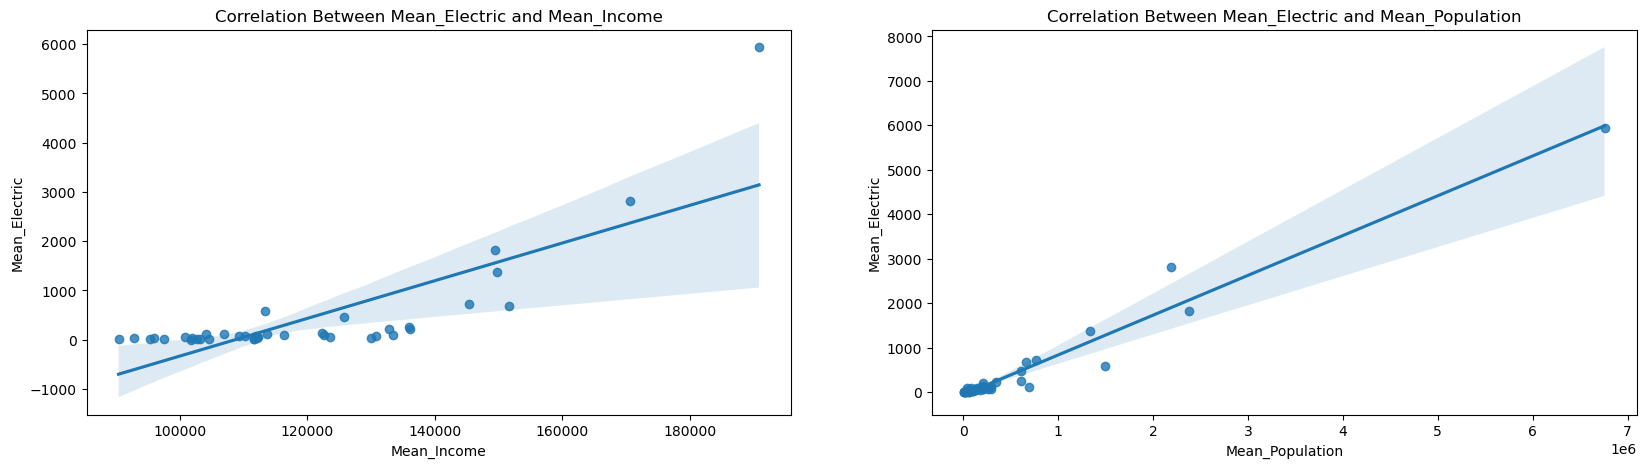

In [18]:
fig, axs=plt.subplots(1,2, figsize=(20,5))
sns.regplot(ax=axs[0], data=inc_ev_corr, x=wa_evgdf['Mean_Income'], y=wa_evgdf['Mean_Electric'])
sns.regplot(ax=axs[1], data=pop_ev_corr, x=wa_evgdf['Mean_Population'], y=wa_evgdf['Mean_Electric'])
axs[0].set_title('Correlation Between Mean_Electric and Mean_Income')
axs[1].set_title('Correlation Between Mean_Electric and Mean_Population')

## Electric, Income and Population Scatter Matrix

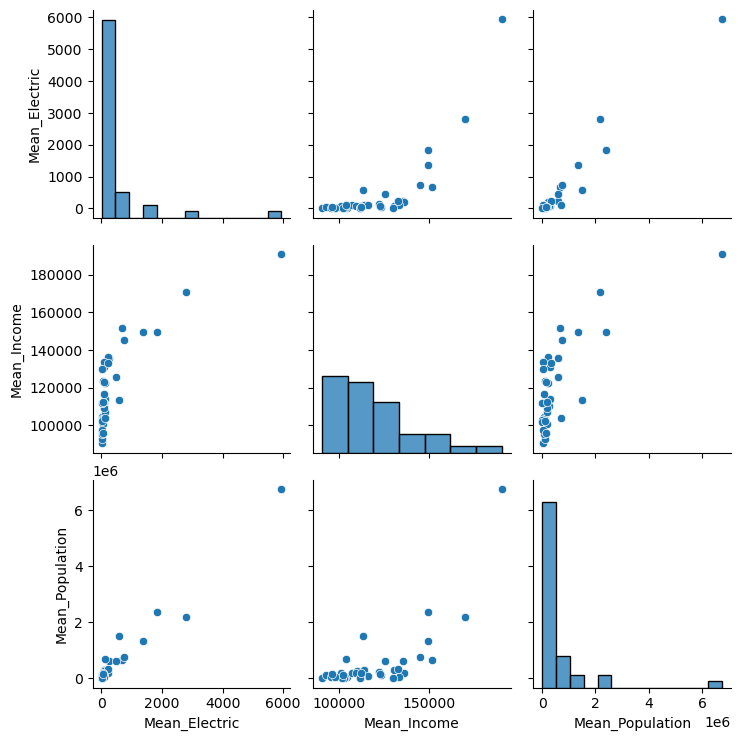

In [25]:
mtrx_df=wa_evgdf[['Mean_Electric','Mean_Income','Mean_Population']]
sns.pairplot(mtrx_df)

<Axes: title={'center': '2025 Electric Vehicles by Type and County'}, xlabel='County'>

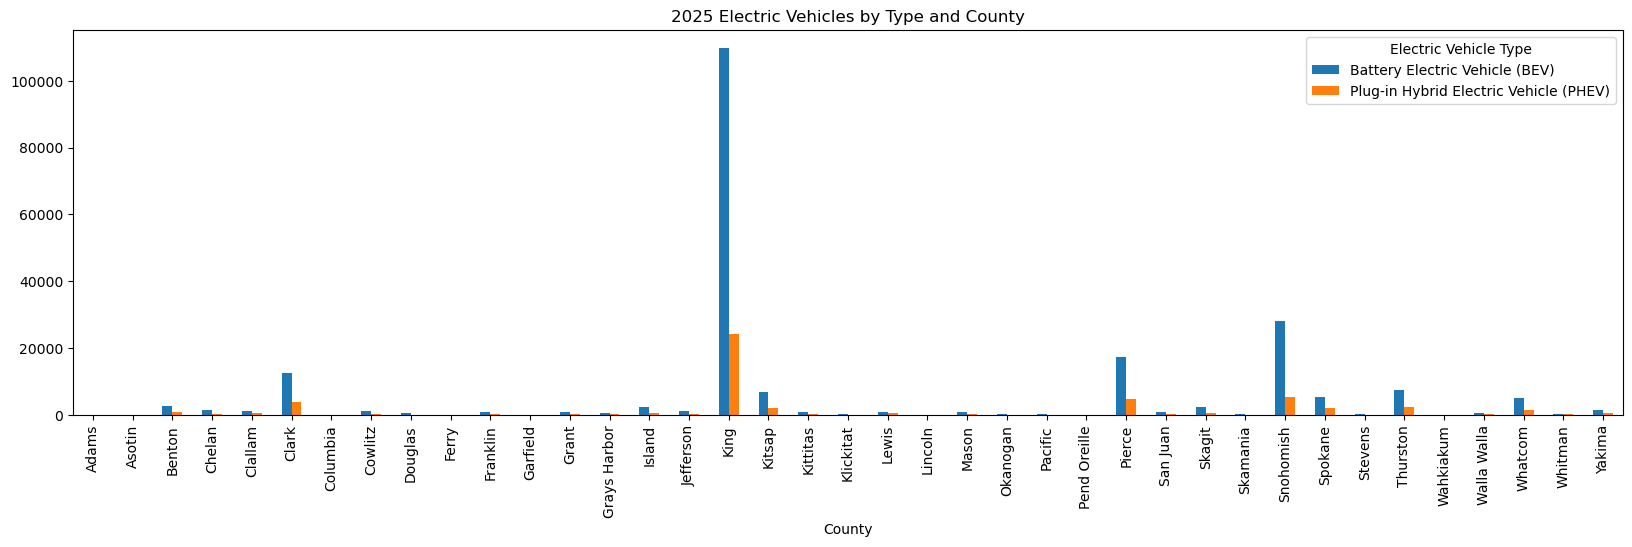

In [16]:
ev_type=wa_evdf['Electric Vehicle Type'].value_counts()
ev_type_county=wa_evdf.groupby('County')['Electric Vehicle Type'].value_counts()
ev_type_county=ev_type_county.to_frame()
ev_type_county_tbl=pd.pivot_table(ev_type_county,index='County', values='count', columns='Electric Vehicle Type')
ev_type_county_tbl.plot(kind='bar', figsize=(20,5),title='2025 Electric Vehicles by Type and County')

## WA State Popular EVs by Makes and Models (2025)

Text(0.5, 1.0, 'Top 10 Models')

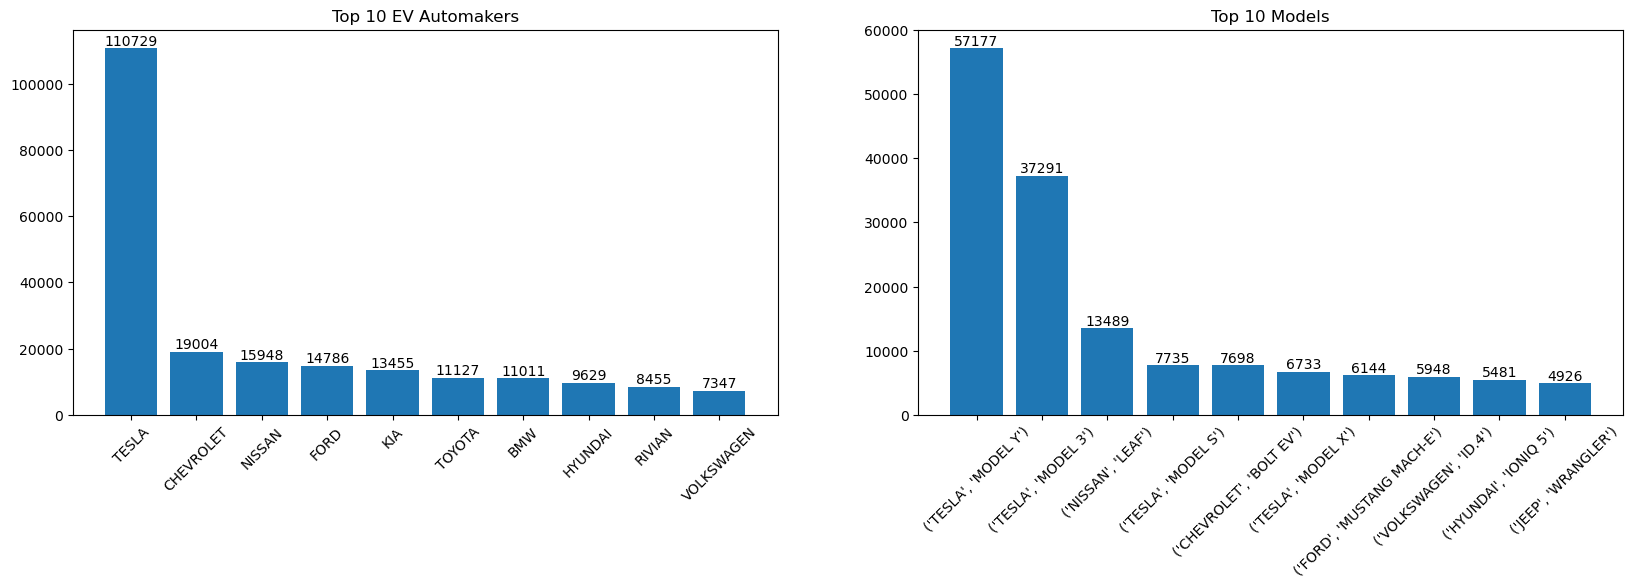

In [19]:
fig, axs=plt.subplots(1,2, figsize=(20,5))


ev_mk=wa_evdf.groupby(by='Make')['Make'].value_counts().to_frame().nlargest(10,'count')
ev_mk_mdl=wa_evdf.groupby(['Make','Model']).size().nlargest(10).to_frame()
mk_mdl=tuple(ev_mk_mdl.index)
mk=tuple(ev_mk.index)
x=np.arange(0,(len(mk)))
x1=np.arange(0,len(ev_mk_mdl))
for (att, mea),(att1,mea1) in zip((ev_mk.items()),(ev_mk_mdl.items())):
    t=axs[0].bar(x,mea,label=att)
    axs[0].bar_label(t)
    s=axs[1].bar(x1,mea1, label=att1)
    axs[1].bar_label(s)

axs[0].set_xticks(x,mk, rotation=45)
axs[1].set_xticks(x1,mk_mdl, rotation=45)
axs[0].set_title('Top 10 EV Automakers')
axs[1].set_title('Top 10 Models')


    
    #t=ev_mk.plot.bar(ax=axs[0],title='Top 10 EV Automakers', legend=False, ylabel='Number of Vehicles', label=att) # grouping the top 10 EV automakers
               #.plot.bar(title='Top 10 EV Automakers', legend=False, ylabel='Number of Vehicles')
    #axs[0].bar_label(t)
#ev_mk.plot(ax=axs[0], kind='bar', title='Top 10 EV Automakers', legend=False, ylabel='Number of Vehicles')# plotting the top 10 EV automakers
#ev_mk_mdl=wa_evdf.groupby(['Make','Model']).size().nlargest(10).plot(ax=axs[1],kind='bar', title='Top 10 Models', ylabel='Number of Vehicles')#.nlargest(10).to_frame()# grouping and plotting the top 10 models

Text(0.5, 0.98, 'TOP 4 MAKES BY MODEL')

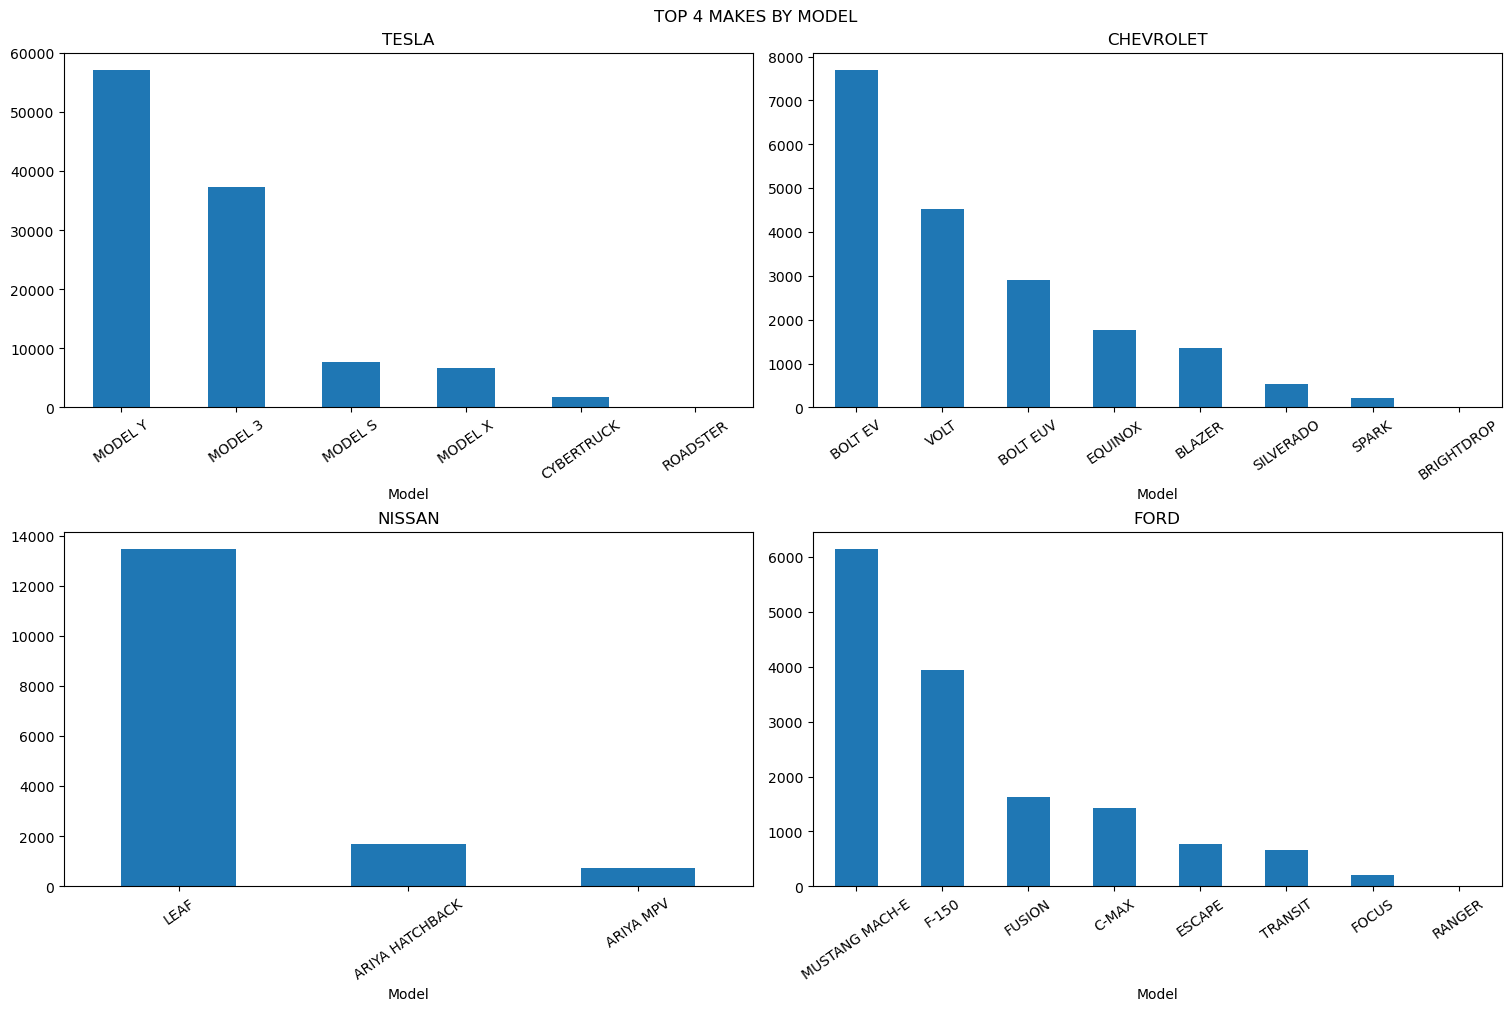

In [82]:

fig, axs=plt.subplots(2,2, figsize=(15,10),layout='constrained')


l=wa_evdf.set_index('Make').loc[['TESLA','CHEVROLET','NISSAN','FORD']] # Setting Make as index to facilitate selection
#'KIA']]#,'TOYOTA','BMW','HYUNDAI','RIVIAN','VOLKSWAGEN']]
l=l.groupby(['Make'])# Creating a groupby object for later access

tesla=l.get_group(('TESLA',))['Model'].value_counts()
tesla.plot(kind='bar', ax=axs[0,0], title='TESLA', rot=35)

chevy=l.get_group(('CHEVROLET',))['Model'].value_counts()
chevy.plot(kind='bar', ax=axs[0,1], title='CHEVROLET', rot=35)

nissan=l.get_group(('NISSAN',))['Model'].value_counts()
nissan.plot(kind='bar', ax=axs[1,0], title='NISSAN', rot=35)

ford=l.get_group(('FORD',))['Model'].value_counts()
ford.plot(kind='bar', ax=axs[1,1], title='FORD', rot=35)

fig.suptitle('TOP 4 MAKES BY MODEL')

#l_tbl=pd.pivot_table(l,index='Make', values='count', columns='Model')
#l_tbl.plot(kind='bar',figsize=(15,5),legend=True, width=1, rot=0) (Another option to see the same plots)

# To add bar labels, we can transform each group into a df, then iterate through the items/values of each (as above)
   
    